# Visualisation of embeddings' distributions

## Requirements

In [1]:
import os
import sys
import json
from typing import Dict
from pathlib import Path
sys.path.insert(0, os.path.join("..", "..", "src"))

import deeplake
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt



# ==================
#   PATH CONSTANTS
# ==================
import os
from pathlib import Path
ROOT_DIR = "/home/leolr-int/nfs/AGGCPerturbations"
#ROOT_DIR = str(Path(__file__).resolve().parents[2])
SRC_DIR = os.path.join(ROOT_DIR, "src")
ASSET_DIR = os.path.join(ROOT_DIR, "assets")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")
PROFILING_DIR = os.path.join(ROOT_DIR, "profiling")
#DATA_DIR = os.path.join(ROOT_DIR, "data")
#DATA_DIR = '/home/leolr-int/nfs/data/data'
DATA_DIR = '/home/leolr-int/nfs/transformed_data/KFBio_FDA_deeplake'
RAW_DIR = os.path.join(DATA_DIR, "raw")
RUN_DIR = os.path.join(ROOT_DIR, "tensorboard")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
CONFIG_DIR = os.path.join(ROOT_DIR, "configs")
PATCH_DIR = os.path.join(DATA_DIR, "patched")
#METADATA_DIR = os.path.join(DATA_DIR, "metadata")
METADATA_DIR = '/home/leolr-int/nfs/data/data/metadata'
#EMBEDDING_DIR = os.path.join(ROOT_DIR, "embeddings")
EMBEDDING_DIR = '/home/leolr-int/nfs/transformed_data/new_embeddings'

PATCH_TABLE_DIR = os.path.join(DATA_DIR, "patch_tables")
BASE_MODEL_DIR = os.path.join(ROOT_DIR, "model_weights")
FULL_PATCH_DIR = os.path.join(DATA_DIR, "patched_full") # only used for downstream analysis
HISTOGRAM_DIR = os.path.join(DATA_DIR, "histogram_matching_stats")
COMBINED_PATCH_DIR = os.path.join(DATA_DIR, "patched_combined")

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

COLOR_MAP = {
    0: [242, 182, 216],   
    1: [163, 196, 243],  
    2: [255, 213, 128],   
    3: [190, 224, 200],   
    4: [217, 185, 255],   
}

SEVERITY_COLOR_MAP = {
    0: [255, 0,     255],
    1: [51,  0,     255],
    2: [51,  255,   0  ],
    3: [255, 229.5, 0  ],
    4: [255, 0,     0  ]
}

import os
import json
import yaml
import pickle
from typing import Dict, Union, Any

def get_args(args_path: str) -> Dict[str, Union[float | str]]:

    """
    Gets relevant arguments from a yaml file.

    Parameters
    ----------
    args_path: str
        The path to the yaml file containing the arguments.
    
    Returns
    -------    
    args: Dict[str, Union[float, str]]
        The arguments in the form of a dictionary.
    """

    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    return args


import torch
import random
import numpy as np

def set_seed(seed: int) -> None:
    """
    Sets the seed for reproducibility.

    Parameters
    ----------
    seed: int
        The seed to use.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True



/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Visualisation


In [2]:
def subsample(ds, sample_percantage: float, scanner_name: str, label_map: dict) -> pd.DataFrame:
    if not (0 <= sample_percantage <= 1):
        raise ValueError("sample_percantage must be between 0 and 1")

    unique_labels = np.unique(ds["label"][:]).tolist()
    embeddings, labels, scanners = [], [], []

    for label in tqdm(unique_labels, desc=f"Subsampling {scanner_name}"):
        filtered = ds.query(f"SELECT * WHERE label == {label}")
        indices = np.random.choice(
            len(filtered),
            size=int(len(filtered) * sample_percantage),
            replace=False
        )

        sampled = filtered[*indices]
        embeddings.extend(sampled["embedding"])
        labels.extend(sampled["label"])
        scanners.extend([scanner_name] * len(indices))

    df = pd.DataFrame({
        "embedding": embeddings,
        "label": labels,
        "scanner": scanners
    })

    df["label"] = df["label"].map(label_map)
    return df

In [ ]:
scanners = ['Akoya', 'KFBio', 'KFBio_FDA']
ds_paths = [os.path.join(EMBEDDING_DIR, ds_path, "mixed_precision/dim_256/Train/gigapath") for ds_path in scanners]


id_to_class = {v: k for k, v in LABEL_MAP.items()}
sample_percentage = 0.3  # modify maybe??

dfs = []
for scanner, path in zip(scanners, ds_paths):
    ds = deeplake.open_read_only(path)
    df = subsample(ds, sample_percentage, scanner, id_to_class)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

Subsampling KFBio_FDA: 100%|██████████| 5/5 [00:15<00:00,  3.15s/it]


In [7]:
df_all.head()

,embedding,label,scanner,umap_x,umap_y
0,"[0.11447897, -1.1150676, 0.79885775, -0.854178...",Stroma,Akoya,-5.175134,10.808182
1,"[-1.2254552, -0.123457894, 0.603771, -0.600763...",Stroma,Akoya,-6.227617,10.457109
2,"[-0.73785037, -0.33983132, -0.11311385, 0.8681...",Stroma,Akoya,-5.825881,8.095347
3,"[-0.29496092, 0.40021273, 0.21458164, -0.12807...",Stroma,Akoya,-5.644186,10.146313
4,"[0.26932445, -2.317843, 0.14160407, -0.1430661...",Stroma,Akoya,-6.541875,9.585732


In [4]:
X = np.stack(df_all["embedding"].values)
umap_proj = UMAP(n_components=2, random_state=42).fit_transform(X)
df_all["umap_x"] = umap_proj[:, 0]
df_all["umap_y"] = umap_proj[:, 1]


unique_labels = sorted(df_all["label"].unique())
n_labels = len(unique_labels)



/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


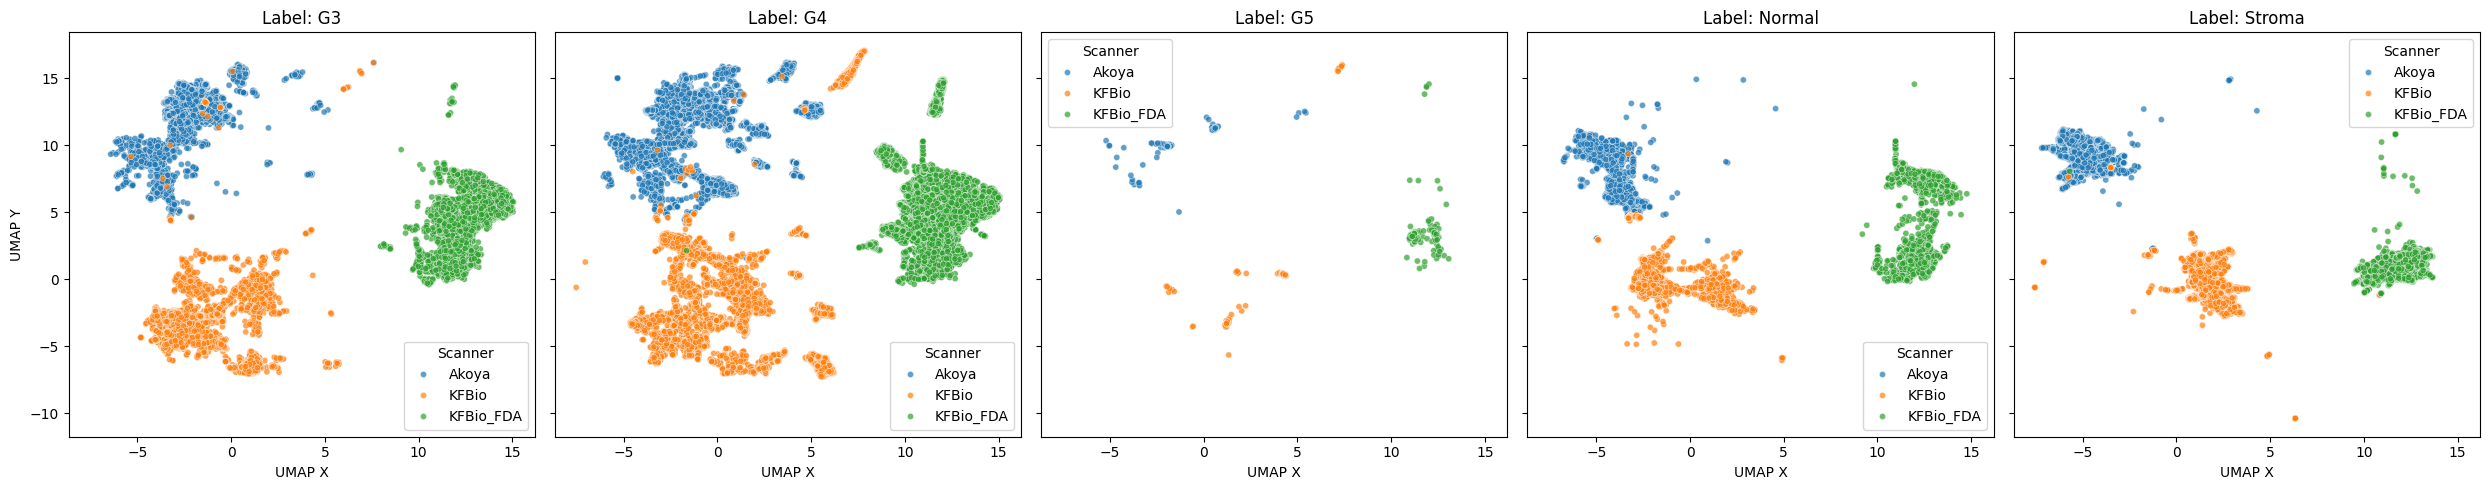

In [5]:
fig, axs = plt.subplots(1, n_labels, figsize=(5 * n_labels, 5), sharex=True, sharey=True)

if n_labels == 1:
    axs = [axs]

for ax, label in zip(axs, unique_labels):
    data = df_all[df_all["label"] == label]
    sns.scatterplot(
        data=data,
        x="umap_x",
        y="umap_y",
        hue="scanner",
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("UMAP X")
    ax.set_ylabel("UMAP Y")
    ax.legend(title="Scanner")

plt.tight_layout()
plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_005.png")
plt.show()


In [6]:
from scipy.spatial.distance import mahalanobis
from itertools import combinations
from collections import defaultdict

# Store results per label
mahalanobis_results = defaultdict(dict)

for label in df_all["label"].unique():
    df_label = df_all[df_all["label"] == label]

    scanners_present = df_label["scanner"].unique()
    for s1, s2 in combinations(scanners_present, 2):
        emb1 = df_label[df_label["scanner"] == s1][["umap_x", "umap_y"]].values
        emb2 = df_label[df_label["scanner"] == s2][["umap_x", "umap_y"]].values

        # Compute pooled covariance matrix
        cov = np.cov(np.vstack((emb1, emb2)).T)
        cov_inv = np.linalg.pinv(cov)

        # Compute centroids
        mu1 = emb1.mean(axis=0)
        mu2 = emb2.mean(axis=0)

        dist = mahalanobis(mu1, mu2, cov_inv)

        mahalanobis_results[label][f"{s1} vs {s2}"] = dist

# Pretty print results
for label, dists in mahalanobis_results.items():
    print(f"\nLabel: {label}")
    for pair, dist in dists.items():
        print(f"  {pair}: {dist:.3f}")


Label: Stroma
  Akoya vs KFBio: 1.948
  Akoya vs KFBio_FDA: 1.992
  KFBio vs KFBio_FDA: 1.952

Label: Normal
  Akoya vs KFBio: 1.898
  Akoya vs KFBio_FDA: 1.994
  KFBio vs KFBio_FDA: 1.976

Label: G3
  Akoya vs KFBio: 1.948
  Akoya vs KFBio_FDA: 1.986
  KFBio vs KFBio_FDA: 1.964

Label: G4
  Akoya vs KFBio: 1.557
  Akoya vs KFBio_FDA: 1.876
  KFBio vs KFBio_FDA: 1.748

Label: G5
  Akoya vs KFBio: 1.935
  Akoya vs KFBio_FDA: 1.980
  KFBio vs KFBio_FDA: 1.923
